In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle

In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 1
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    step=20
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    print("Full run mode")



Quick test mode


In [3]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(300)
else:
    data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxAbsEStateIndex,RDKit_MaxEStateIndex,RDKit_MinAbsEStateIndex,RDKit_MinEStateIndex,RDKit_qed,RDKit_SPS,RDKit_MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,10.634953,0.297618,-0.536525,0.461644,9.833333,172.180,...,1,0,1,1,0,0,0,1,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,12.229922,0.211872,-0.625117,0.322574,10.428571,456.108,...,1,0,1,0,0,1,1,1,1,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,12.333151,0.193012,-0.193012,0.344216,10.625000,420.472,...,0,1,1,0,1,1,1,1,1,0
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,2.263889,0.416667,0.416667,0.351522,6.000000,60.172,...,0,0,0,1,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,8.613426,0.075556,-0.075556,0.609080,9.800000,139.154,...,1,0,1,0,1,1,1,1,1,0


In [4]:
data_with_features['H?'] = data_with_features['MP'].apply(lambda x: 1 if x > 250 else 0)
data_with_features.head()

,SMILES,MP,Type,RDKit_MaxAbsEStateIndex,RDKit_MaxEStateIndex,RDKit_MinAbsEStateIndex,RDKit_MinEStateIndex,RDKit_qed,RDKit_SPS,RDKit_MolWt,...,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166,H?
0,CCOC(=O)/C=C/C(=O)OCC,0.0,train_without_data_augmentation,10.634953,10.634953,0.297618,-0.536525,0.461644,9.833333,172.180,...,0,1,1,0,0,0,1,0,0,0
1,O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...,230.0,train_without_data_augmentation,12.229922,12.229922,0.211872,-0.625117,0.322574,10.428571,456.108,...,0,1,0,0,1,1,1,1,0,0
2,O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...,285.0,train_without_data_augmentation,12.333151,12.333151,0.193012,-0.193012,0.344216,10.625000,420.472,...,1,1,0,1,1,1,1,1,0,1
3,C[SiH2]C,-150.0,train_without_data_augmentation,2.263889,2.263889,0.416667,0.416667,0.351522,6.000000,60.172,...,0,0,1,0,0,0,0,0,0,0
4,OCc1cccc(n1)CO,112.0,train_without_data_augmentation,8.613426,8.613426,0.075556,-0.075556,0.609080,9.800000,139.154,...,0,1,0,1,1,1,1,1,0,0


In [5]:
def feature_engineering_workflow(data_type):

    # Extract all feature columns
    all_feature_cols = data_with_features.drop(columns=['SMILES', 'MP', 'Type', 'H?'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Subset data based on data_type
    if data_type == 'L':
        data = data_with_features[data_with_features['H?'] == 0].reset_index(drop=True)
    if data_type == 'H':
        data = data_with_features[data_with_features['H?'] == 1].reset_index(drop=True)
    print(f"Processing {data_type} dataset with shape: {data.shape}")
    print()

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, scaler_path= data_prefix + f'scaler_{data_type}.pkl', fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()

    def RFE_workflow(df_X_variance, round):
        print()
        print(f'RFE feature selection: Round {round}:')
        # Reduce features by RFE
        RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
        print()

        # Plot RFE results
        hf.RFE_plot(RFE_results)

        # Pickle save the RFE_results
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = df_X_variance[RFE_results['best_features']]

        return df_X_RFE, RFE_results

    # First round of RFE
    df_X_RFE, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    # Feature binary interactions
    df_X_interaction = hf.feature_interaction(df_X_RFE)

    # Second round of RFE
    df_X_final, RFE_results_2 = RFE_workflow(df_X_interaction, 2)


    

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_RFE, RFE_results_2, df_X_final

Total number of features: 384
Processing L dataset with shape: (286, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_L.pkl
✓ Standardization complete. Shape: (286, 384)

Original features: 384
Removed features: 36
Remaining features: 348


RFE feature selection: Round 1:


RFE Feature Selection:   6%|▌         | 1/17 iteration

Iteration 0/17 | Features: 328 | RMSE: 49.4116 ± 9.1375 | Removed: [RDKit_HeavyAtomCount, RDKit_NumAliphaticCarbocycles, RDKit_NumAliphaticHeterocycles, RDKit_NumAliphaticRings, RDKit_NumAromaticCarbocycles, RDKit_NumAromaticRings, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_piperzine, RDKit_fr_pyridine, RDKit_fr_sulfide, RDKit_fr_sulfonamd, RDKit_fr_tetrazole, RDKit_fr_thiazole, RDKit_fr_thiocyan, RDKit_fr_thiophene, RDKit_fr_urea, MACCS_8, MACCS_14, MACCS_16, MACCS_165]


RFE Feature Selection:  65%|██████▍   | 11/17 iteration

Iteration 10/17 | Features: 128 | RMSE: 50.2441 ± 7.7688 | Removed: [RDKit_Chi1, RDKit_Kappa1, RDKit_PEOE_VSA2, RDKit_VSA_EState2, RDKit_NumSaturatedRings, RDKit_fr_COO, RDKit_fr_NH0, RDKit_fr_NH1, RDKit_fr_aldehyde, RDKit_fr_ether, MACCS_45, MACCS_59, MACCS_75, MACCS_76, MACCS_96, MACCS_97, MACCS_101, MACCS_113, MACCS_142, MACCS_144]


RFE Feature Selection: 100%|██████████| 17/17 iteration


Global best RMSE: 48.2052
Threshold (5% tolerance): 50.6154

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 48.2052
  Best features: ['RDKit_AvgIpc', 'RDKit_BertzCT', 'RDKit_SMR_VSA10', 'RDKit_SlogP_VSA1', 'RDKit_TPSA']...



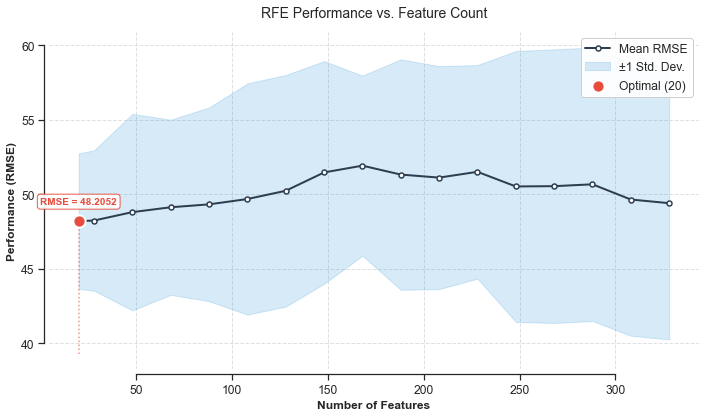

  Optimal Feature Set: 20 features
  Best RMSE: 48.2052
Generating 190 interaction features from 20 original features...

RFE feature selection: Round 2:


RFE Feature Selection:  10%|█         | 1/10 iteration

Iteration 0/10 | Features: 190 | RMSE: 53.5368 ± 8.1010 | Removed: [MACCS_126, MACCS_145, RDKit_NHOHCount X MACCS_109, RDKit_NumBridgeheadAtoms X MACCS_34, RDKit_NumBridgeheadAtoms X MACCS_87, RDKit_NumBridgeheadAtoms X MACCS_104, RDKit_NumBridgeheadAtoms X MACCS_109, RDKit_fr_ester X MACCS_34, RDKit_fr_ester X MACCS_104, RDKit_fr_ester X MACCS_126, RDKit_fr_ester X MACCS_145, MACCS_34 X MACCS_104, MACCS_34 X MACCS_109, MACCS_34 X MACCS_126, MACCS_34 X MACCS_138, MACCS_34 X MACCS_145, MACCS_87 X MACCS_109, MACCS_87 X MACCS_126, MACCS_104 X MACCS_109, MACCS_138 X MACCS_145]


RFE Feature Selection: 100%|██████████| 10/10 iteration


Global best RMSE: 48.4088
Threshold (5% tolerance): 50.8292

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 50.7419
  Best features: ['RDKit_BertzCT', 'RDKit_TPSA', 'RDKit_AvgIpc X RDKit_TPSA', 'RDKit_AvgIpc X RDKit_NHOHCount', 'RDKit_AvgIpc X MACCS_138']...



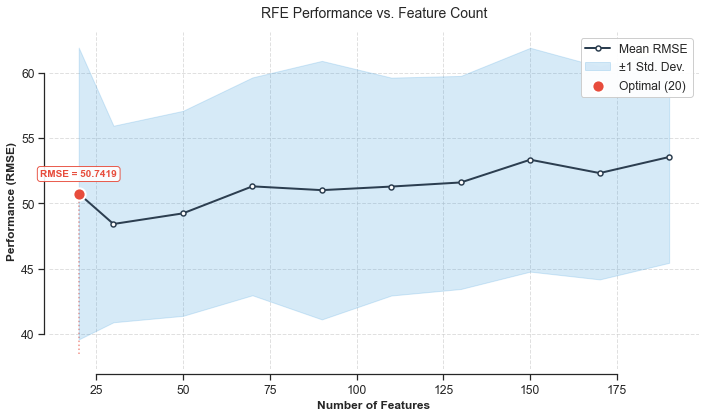

  Optimal Feature Set: 20 features
  Best RMSE: 50.7419


In [6]:
df_L_X_scaled, df_L_X_variance, RFE_results_L_1, df_L_X_RFE, RFE_results_L_2, df_L_X_final = feature_engineering_workflow('L')

In [7]:
df_H_X_scaled, df_H_X_variance, RFE_results_H_1, df_H_X_RFE, RFE_results_H_2, df_H_X_final = feature_engineering_workflow('H')

Total number of features: 384
Processing H dataset with shape: (14, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_H.pkl
✓ Standardization complete. Shape: (14, 384)

Original features: 384
Removed features: 117
Remaining features: 267


RFE feature selection: Round 1:


RFE Feature Selection:   0%|          | 0/13 iteration

RFE Feature Selection:   8%|▊         | 1/13 iteration

Iteration 0/13 | Features: 247 | RMSE: 24.8036 ± 11.4272 | Removed: [RDKit_fr_Imine, MACCS_41, MACCS_42, MACCS_43, MACCS_45, MACCS_46, MACCS_47, MACCS_49, MACCS_50, MACCS_52, MACCS_54, MACCS_56, MACCS_57, MACCS_62, MACCS_63, MACCS_65, MACCS_69, MACCS_70, MACCS_71, MACCS_72]


RFE Feature Selection:  23%|██▎       | 3/13 iteration

KeyboardInterrupt: 

In [ ]:
def combine_features(df_L_X_final, df_H_X_final):

    # Number of features in each set
    n_features_L = df_L_X_final.shape[1]
    n_features_H = df_H_X_final.shape[1]
    print(f"Number of features in L dataset: {n_features_L}")
    print(f"Number of features in H dataset: {n_features_H}")

    # Number of overlapping features
    overlapping_features = set(df_L_X_final.columns).intersection(set(df_H_X_final.columns))
    n_overlapping_features = len(overlapping_features)
    print(f"Number of overlapping features: {n_overlapping_features}")
    print(f"Overlapping features: {overlapping_features}")

    # Combine features
    combined_features = list(set(df_L_X_final.columns).union(set(df_H_X_final.columns)))
    print(f"Total number of combined features: {len(combined_features)}")

    return combined_features

In [ ]:
selected_features = combine_features(df_L_X_final, df_H_X_final)

Number of features in L dataset: 26
Number of features in H dataset: 20
Number of overlapping features: 0
Overlapping features: set()
Total number of combined features: 46


# Example showing how to get a dataset with the selected features

In [ ]:
df_to_test_the_code = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').tail(500)

In [ ]:
df = hf.dataset_featurization(df_to_test_the_code, selected_features, data_prefix + 'to_test_the_code')
df

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_hel

✓ RDKit: Added 217 features


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: D

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 original features...
../data_curation/processed_data/to_test_the_code dataset saved.


,SMILES,MP,Type,RDKit_MinPartialCharge X RDKit_Kappa3,RDKit_TPSA X MACCS_138,RDKit_qed,RDKit_BCUT2D_LOGPLOW,RDKit_AvgIpc X RDKit_HallKierAlpha,RDKit_MaxAbsEStateIndex,RDKit_BCUT2D_MWLOW,...,RDKit_PEOE_VSA12 X RDKit_fr_bicyclic,RDKit_MaxAbsEStateIndex X RDKit_SlogP_VSA2,RDKit_TPSA,RDKit_SlogP_VSA2,RDKit_SMR_VSA10 X RDKit_NHOHCount,RDKit_TPSA X MACCS_145,RDKit_SPS,RDKit_BertzCT,RDKit_BertzCT X MACCS_114,RDKit_Chi4v X RDKit_Kappa3
17133,O=c1oc2ccccc2c(c1C(c1c(=O)oc2c(c1O)cccc2)C)O,178.0,train_without_data_augmentation,-1.148503,0.00,0.536991,-2.178538,-9.257572,12.414025,9.920856,...,0.0,126.785119,100.88,10.213055,43.876977,100.88,11.461538,1165.758195,0.00000,7.263405
17134,CC(=O)Nc1ccc(c(c1)C(F)(F)F)Br,118.0,train_without_data_augmentation,-1.053435,0.00,0.839657,-2.095681,-2.133682,12.423442,10.166371,...,0.0,73.387502,29.10,5.907180,27.524510,0.00,11.266667,389.434114,0.00000,4.826007
17135,NC(=O)c1ccccc1O,140.0,train_without_data_augmentation,-0.545102,0.00,0.591271,-2.100265,-2.836904,10.483981,10.175925,...,0.0,115.467502,63.32,11.013707,17.721539,0.00,9.200000,257.537949,0.00000,0.733078
17136,COc1cc(N)c(cc1C(=O)NC1CCN(CC1)Cc1ccccc1)Cl,194.0,train_without_data_augmentation,-2.220674,67.59,0.788745,-2.439683,-5.950334,12.624512,10.029506,...,0.0,467.715960,67.59,37.048241,69.586518,67.59,15.615385,759.151653,0.00000,15.313580
17137,O=C([C@@H]1CC=CC[C@@H]1C(=O)O)OC(=O)[C@H]1CC=C...,100.0,train_without_data_augmentation,-1.853742,0.00,0.455906,-2.373070,-6.200592,12.136833,9.818710,...,0.0,413.747985,117.97,34.090276,47.754442,117.97,29.739130,524.977825,0.00000,11.352745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17628,[O-][N+](=O)CCO,-80.0,train_without_data_augmentation,-1.308890,63.37,0.359142,-2.032127,-0.863096,9.244861,10.745645,...,0.0,214.309533,63.37,23.181477,0.000000,0.00,8.166667,52.754888,0.00000,0.274343
17629,N#CCc1ccc(cc1)OC(=O)C,50.0,train_without_data_augmentation,-1.261443,0.00,0.507173,-2.004637,-3.781566,10.549225,10.153343,...,0.0,62.971547,50.09,5.969305,0.000000,0.00,8.923077,334.937533,0.00000,2.756797
17630,CCOC(=O)/C(=N\Nc1ccc(cc1)[N+](=O)[O-])/C(=O)C(...,184.0,train_without_data_augmentation,-2.330152,0.00,0.280363,-2.370692,-7.350955,12.426538,10.216763,...,0.0,437.050367,110.90,35.170727,28.839008,0.00,11.739130,640.336510,640.33651,6.574125
17631,O/N=C/1\C(=O)N(N=C1c1ccc(cc1)[N+](=O)[O-])c1cc...,223.0,train_without_data_augmentation,-1.036400,0.00,0.532045,-2.274020,-10.364400,12.308221,10.060469,...,0.0,337.997464,108.40,27.461114,28.705322,108.40,15.826087,828.315198,0.00000,5.468576
